<a href="https://colab.research.google.com/github/DiFedorchuk/ML_Course/blob/main/HW_2_5_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
pip install darts --quiet

In [4]:
pip install darts statsforecast --quiet

In [41]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict
from statsmodels.tsa.seasonal import seasonal_decompose
from darts import TimeSeries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from darts.utils.statistics import plot_acf, check_seasonality
from darts.models import NaiveSeasonal, NaiveDrift, XGBModel, ExponentialSmoothing, AutoARIMA, Theta, ARIMA, RNNModel
from darts.metrics import mape
from darts.dataprocessing.transformers import Scaler
from prophet import Prophet

In [6]:
raw_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/train.csv.zip")

In [7]:
raw_df['date'] = pd.to_datetime(raw_df['date'])
raw_df.set_index('date', inplace=True)

In [8]:
raw_df.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [9]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [10]:
# 1. Total daily sales for all stores and items
total_daily_sales = raw_df.groupby('date')['sales'].sum().reset_index()
fig1 = px.line(total_daily_sales, x='date', y='sales', title='Total daily sales for all stores and items')
fig1.show()

# 2. Sales for  item "1" across all stores
item1_sales_agg = raw_df[raw_df['item'] == 1].groupby('date')['sales'].agg(['mean', 'min', 'max']).reset_index()
item1_sales_melted = item1_sales_agg.melt(id_vars=['date'], value_vars=['mean', 'min', 'max'], var_name='Metric', value_name='Sales')
fig2 = px.line(item1_sales_melted, x='date', y='Sales', color='Metric', title='Sales for item "1" across all stores')
fig2.show()

# 3. Store "1" sales for all items
store1_sales_agg = raw_df[raw_df['store'] == 1].groupby('date')['sales'].agg(['mean', 'min', 'max']).reset_index()
store1_sales_melted = store1_sales_agg.melt(id_vars=['date'], value_vars=['mean', 'min', 'max'], var_name='Metric', value_name='Sales')
fig3 = px.line(store1_sales_melted, x='date', y='Sales', color='Metric', title='Store "1" sales for all items')
fig3.show()

# 4. Total daily sales with rolling Mean (Trend)
total_daily_sales['rolling_mean'] = total_daily_sales['sales'].rolling(window=30).mean()
fig4 = go.Figure()
fig4.add_trace(go.Scatter(x=total_daily_sales['date'], y=total_daily_sales['sales'], mode='lines', name='Total Daily Sales', opacity=0.7))
fig4.add_trace(go.Scatter(x=total_daily_sales['date'], y=total_daily_sales['rolling_mean'], mode='lines', name='Rolling mean (Trend)', line=dict(color='red', width=2)))
fig4.update_layout(title='Total daily sales with rolling Mean (Trend)', xaxis_title='Date', yaxis_title='Sales')
fig4.show()

Observation: from visualizations we can see  a seasonal pattern sales increase at the end of each year and decrease at the beginning. Over the past five years, there has been an increase in total sales, which indicates more stable growth. There is significant variability in daily sales volumes, both for individual products across different stores and for different products within the same store. A rolling mean effectively smooths out daily fluctuations, making underlying annual cycles and the steady upward trend much more visible



3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [11]:
item1_store_1 = raw_df[(raw_df['item'] == 1) & (raw_df['store'] == 1)]

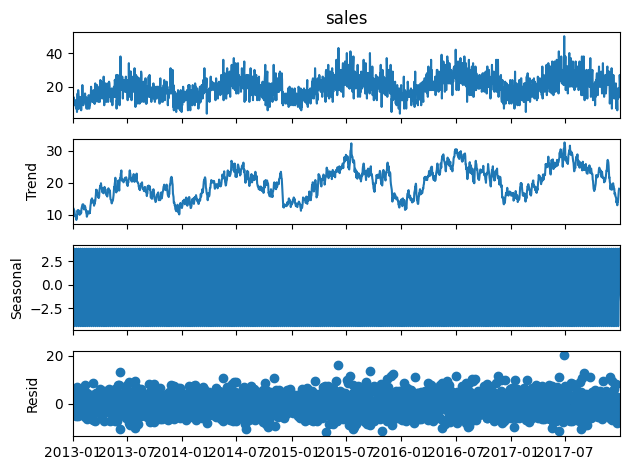

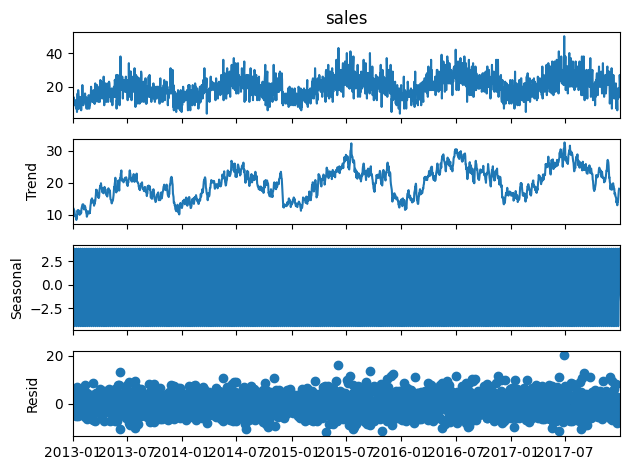

In [12]:
decomposition_plot_additive = seasonal_decompose(item1_store_1['sales'],
                                              model='additive')
decomposition_plot_additive.plot()

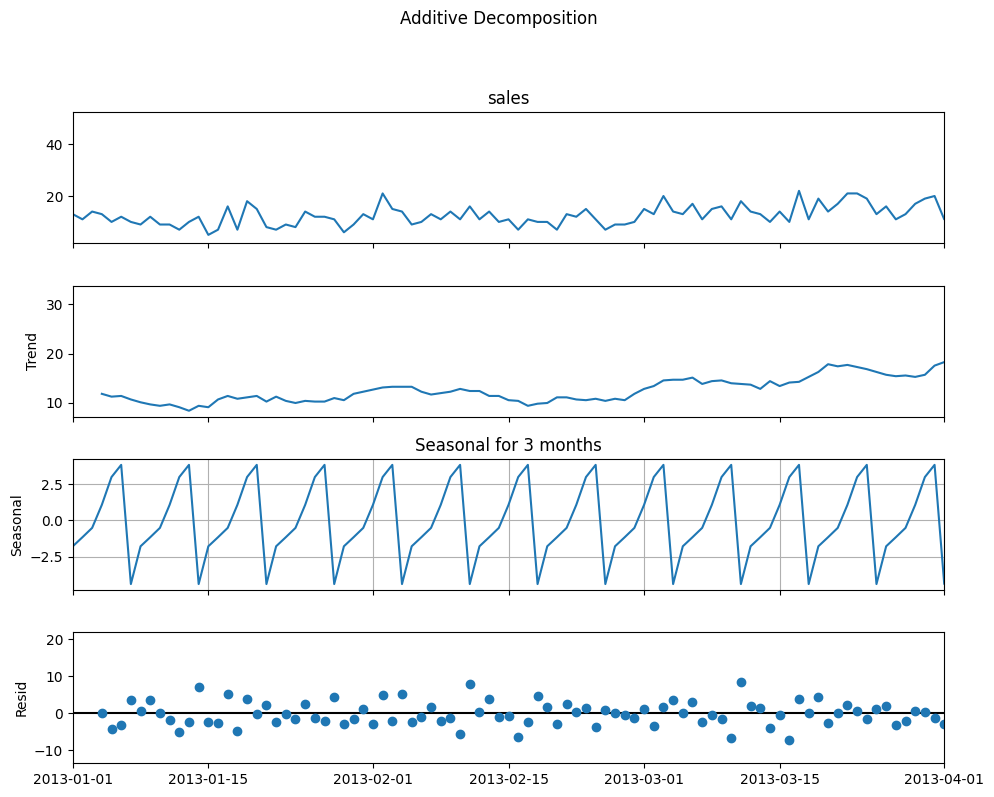

In [13]:
decomposition_plot_additive = seasonal_decompose(item1_store_1['sales'],
                                              model='additive')
# 3-month sales chart provides more insight for analyzing seasonality
fig = decomposition_plot_additive.plot()
fig.set_size_inches(10, 8)

ax_seasonal = fig.axes[2]
ax_seasonal.set_title('Seasonal for 3 months')
ax_seasonal.set_xlim(pd.Timestamp('2013-01-01'), pd.Timestamp('2013-04-01'))
ax_seasonal.grid(True)

plt.suptitle('Additive Decomposition', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


Observations: The visualization shows a clear increasing trend, sales volumes show clear seasonality throughout the year, with noticeable peaks at the end of each year  and drops at the beginning, zoomed-in graph of seasonal trends for the first three months clearly shows weekly patterns, sales volumes are generally higher in the middle and at the end of the week and lower at the beginning of the week.

Residuals looks like  random in nature and do not exhibit any obvious patterns, suggesting that the additive model has covered a significant portion of the trend and seasonal fluctuations.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [14]:
series_item1_store = TimeSeries.from_series(item1_store_1['sales'])

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

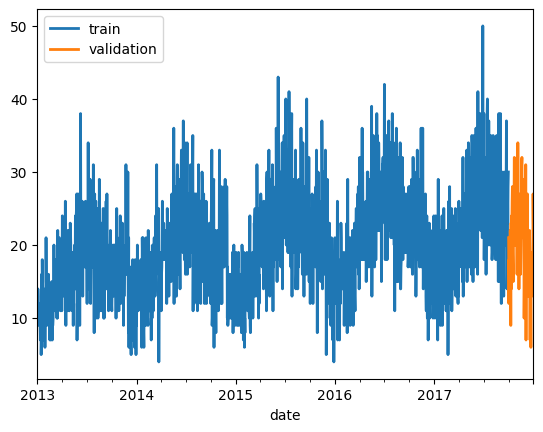

In [15]:
train_series, val_series = series_item1_store.split_before(pd.Timestamp('2017-10-01'))
train_series.plot(label='train')
val_series.plot(label='validation')
plt.legend()

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1200x600 with 0 Axes>

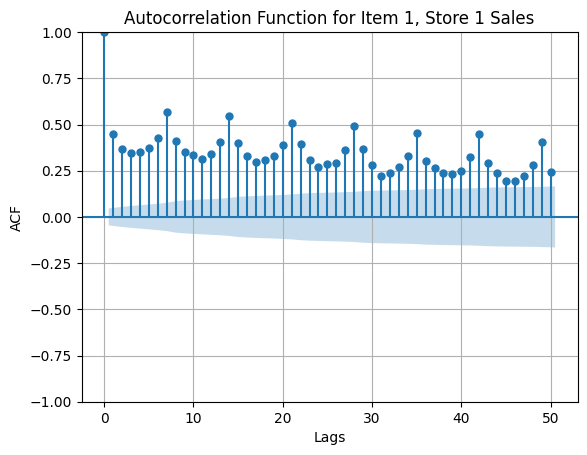

<Figure size 1200x600 with 0 Axes>

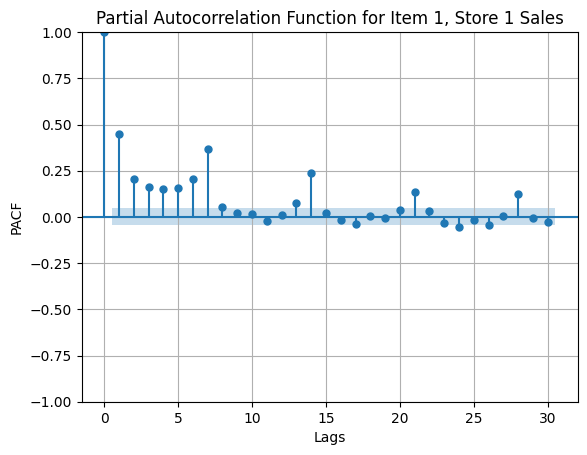

In [23]:

#ACF
plt.figure(figsize=(12, 6))
sm_plot_acf(series_item1_store.values(), lags=50)
plt.title('Autocorrelation Function for Item 1, Store 1 Sales')
plt.xlabel('Lags')
plt.ylabel('ACF')
plt.grid(True)
plt.show()

#PACF
plt.figure(figsize=(12, 6))
sm_plot_pacf(series_item1_store.values(), lags=30)
plt.title('Partial Autocorrelation Function for Item 1, Store 1 Sales')
plt.xlabel('Lags')
plt.ylabel('PACF')
plt.grid(True)
plt.show()

Observation:
ACF: Plot shows a relatively slow decline, which  indicates the presence of a trend. Positive autocorrelation at early lags, ACF values for the initial lags are very high and positive, indicating strong robustness of sales. Significant peaks are observed at lags of 7, 14, 21, 28, 35, 42, 49. These peaks, which occur every 7 days, clearly indicate the presence of a weekly seasonal pattern in the sales

PACF: Positive peak is observed at lag 1, indicating a significant positive correlation with the previous days sales after accounting for sales at earlier lags. Significant peaks are present at lags 7, 14, 21. These peaks, which occur at multiples of 7, confirm the presence of strong weekly seasonality. After the initial lag and seasonal lags, the PACF values drop rapidly within the confidence intervals, which indicates that only a few immediately previous values have a direct impact on the current value after accounting for lag effects

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

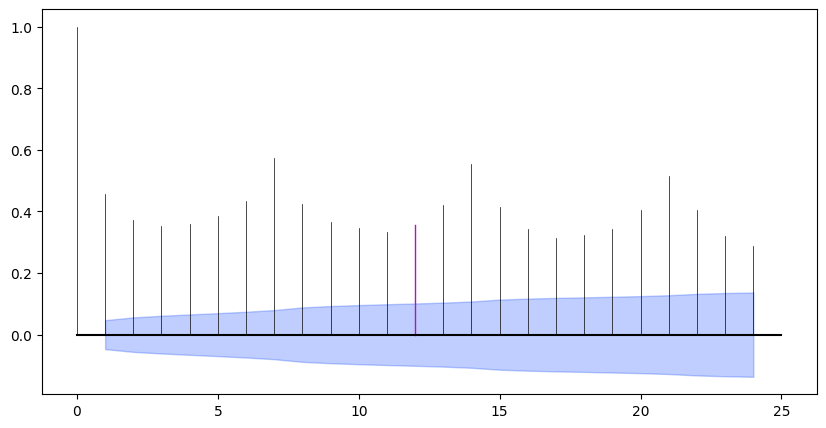

In [24]:
plot_acf(train_series, m=12, alpha=0.05, max_lag=24)

In [25]:
for m in range(2, 25):
    is_seasonal, period = check_seasonality(train_series, m=m, alpha=0.05)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


Observation: can observe a weekly seasonal pattern in the sales

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

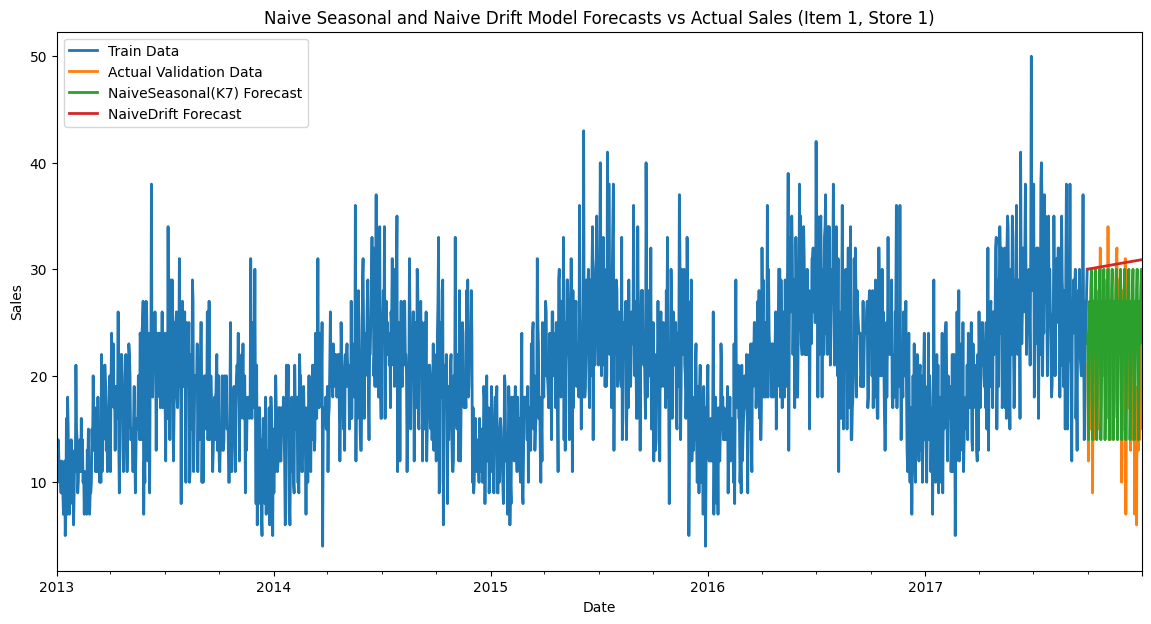

In [26]:
n_forecast_steps = len(val_series)
# NaiveSeasonal model (weekly seasonality)
seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train_series)
seasonal_forecast = seasonal_model.predict(n_forecast_steps)
# NaiveDrift model
drift_model = NaiveDrift()
drift_model.fit(train_series)
drift_forecast = drift_model.predict(n_forecast_steps)

plt.figure(figsize=(14, 7))
train_series.plot(label='Train Data')
val_series.plot(label='Actual Validation Data')
seasonal_forecast.plot(label='NaiveSeasonal(K7) Forecast')
drift_forecast.plot(label='NaiveDrift Forecast')
plt.title('Naive Seasonal and Naive Drift Model Forecasts vs Actual Sales (Item 1, Store 1)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

Observation: NaiveSeasonal model effectively captures weekly fluctuations but fails to account for the overall trend. NaiveDrift model captures the long-term trend but completely ignores the pronounced weekly seasonality. None of these models, on its own, provides an accurate forecast for this time series

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [27]:
print(f"Mean absolute percentage error for NaiveSeasonal model: {mape(val_series, seasonal_forecast):.2f}%")
print(f"Mean absolute percentage error for NaiveDrift model: {mape(val_series, drift_forecast):.2f}%")
combined_forecast = (seasonal_forecast + drift_forecast) / 2
print(f"Mean absolute percentage error for combined NaiveSeasonal + NaiveDrift: {mape(val_series, combined_forecast):.2f}%")

Mean absolute percentage error for NaiveSeasonal model: 38.17%
Mean absolute percentage error for NaiveDrift model: 68.74%
Mean absolute percentage error for combined NaiveSeasonal + NaiveDrift: 49.11%


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

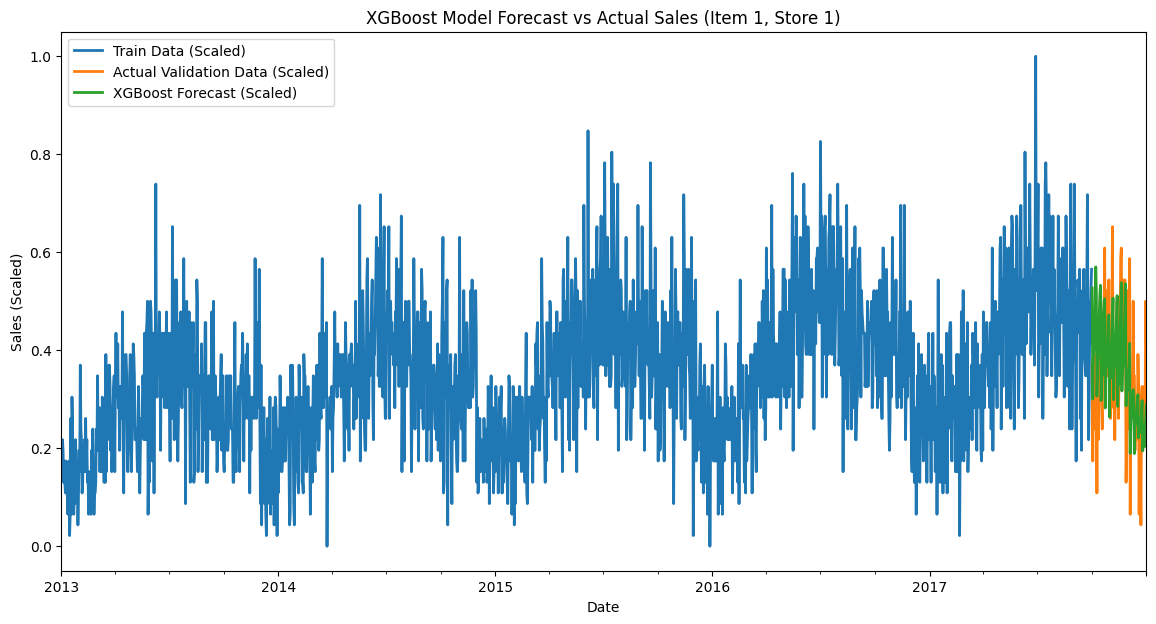

Mean absolute percentage error for XGBoost model: 22.64%


In [28]:
def enrich_with_date_features(df):
  df["dayofweek"] = df['Month'].dt.dayofweek
  df["quarter"] = df['Month'].dt.quarter
  df["month"] = df['Month'].dt.month
  df["year"] = df['Month'].dt.year
  df["dayofyear"] = df['Month'].dt.dayofyear
  df["sin_day"] = np.sin(df["dayofyear"])
  df["cos_day"] = np.cos(df["dayofyear"])
  return df

# Generate full covariates for the entire dataset
full_df_for_covariates = item1_store_1.reset_index().rename(columns={'date': 'Month'})
full_features_df = enrich_with_date_features(full_df_for_covariates.copy())
# Drop the target and identification columns to form pure covariates
full_covariates_df = full_features_df.drop(columns=['sales', 'store', 'item']).set_index('Month')
full_covariates_series = TimeSeries.from_dataframe(full_covariates_df)

# Split main series for training and validation
train_series, val_series = series_item1_store.split_before(pd.Timestamp('2017-10-01'))

# Scale target series
target_scaler = Scaler()
scaled_train_series = target_scaler.fit_transform(train_series)
scaled_val_series = target_scaler.transform(val_series)

# Scale all covariates using the same scaler
covariate_scaler = Scaler()
scaled_full_covariates_series = covariate_scaler.fit_transform(full_covariates_series)

# Extract scaled train covariates (aligned with scaled_train_series)
scaled_train_covariates = scaled_full_covariates_series.drop_after(train_series.end_time())

# Construct the `past_covariates` for the `predict` method
required_cov_start = pd.Timestamp('2017-09-18')
required_cov_end = pd.Timestamp('2017-12-31')

# Slice the scaled full covariates to match the required range for prediction
scaled_covariates_for_prediction = scaled_full_covariates_series.drop_before(required_cov_start).drop_after(required_cov_end)

# Build and train XGBoost model
model = XGBModel(
    lags=12,
    lags_past_covariates=list(range(-12, 0)),
    output_chunk_length=1,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# Train the model with scaled target and scaled train covariates
model.fit(series=scaled_train_series, past_covariates=scaled_train_covariates)
# Predict using the model, providing the correctly sliced covariates
pred = model.predict(n=len(val_series), past_covariates=scaled_covariates_for_prediction)

plt.figure(figsize=(14, 7))
scaled_train_series.plot(label='Train Data (Scaled)')
scaled_val_series.plot(label='Actual Validation Data (Scaled)')
pred.plot(label='XGBoost Forecast (Scaled)')
plt.title('XGBoost Model Forecast vs Actual Sales (Item 1, Store 1)')
plt.xlabel('Date')
plt.ylabel('Sales (Scaled)')
plt.legend()
plt.show()

# Calculate MAPE
unscaled_val_series = target_scaler.inverse_transform(scaled_val_series)
unscaled_pred = target_scaler.inverse_transform(pred)
mape_xgb = mape(unscaled_val_series, unscaled_pred)
print(f"Mean absolute percentage error for XGBoost model: {mape_xgb:.2f}%")

Observation: The visualization showed that, although the model captured the overall trend and certain seasonal patterns, it still struggled to accurately predict sharp peaks and troughs in the sales

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

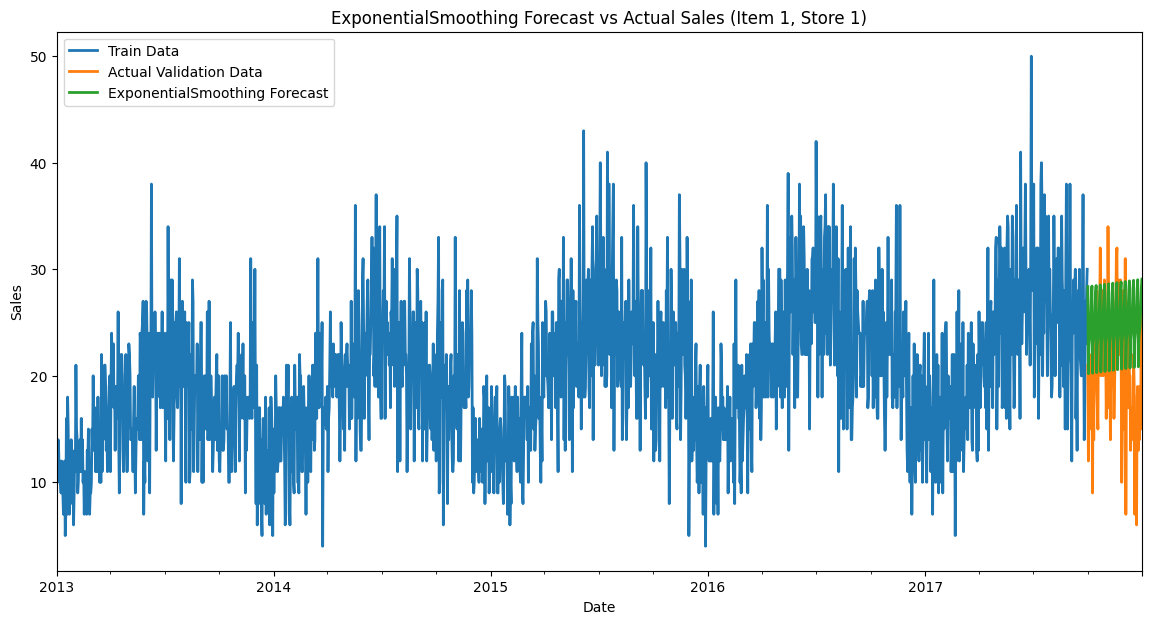

MAPE for ExponentialSmoothing: 39.01%


In [29]:
model_exp = ExponentialSmoothing()
model_exp.fit(train_series)
exp_forecast = model_exp.predict(len(val_series))

plt.figure(figsize=(14, 7))
train_series.plot(label='Train Data')
val_series.plot(label='Actual Validation Data')
exp_forecast.plot(label='ExponentialSmoothing Forecast')
plt.title('ExponentialSmoothing Forecast vs Actual Sales (Item 1, Store 1)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# MAPE
mape_exp = mape(val_series, exp_forecast)
print(f"MAPE for ExponentialSmoothing: {mape_exp:.2f}%")

Observation: ExponentialSmoothing model showed a MAPE = 39.01%. Visually, the model captures the general trend, but, like the NaiveSeasonal model, it struggles with pronounced seasonality and sharp peaks and troughs in the sales data. It performed better than the NaiveDrift model and the combination of NaiveSeasonal and NaiveDrift, but significantly worse than the XGBoost model

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

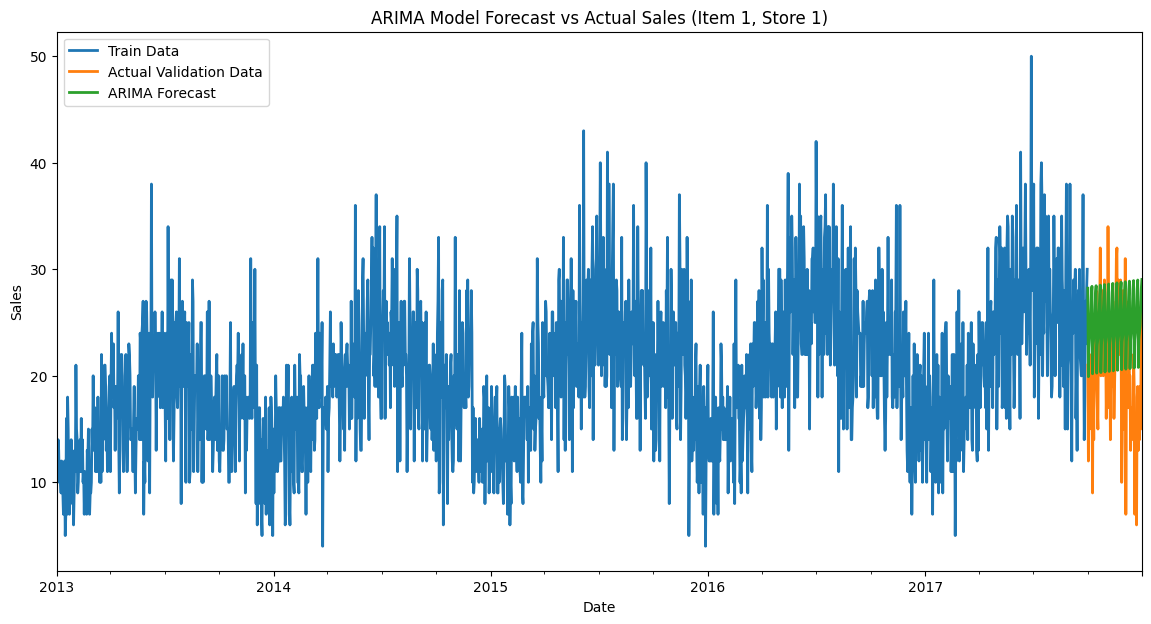

MAPE for ARIMA model: 38.86%


In [30]:
model_arima = ARIMA(p=1, d=1, q=1, seasonal_order=(1, 1, 1, 7))
model_arima.fit(train_series)
arima_forecast = model_arima.predict(len(val_series))

plt.figure(figsize=(14, 7))
train_series.plot(label='Train Data')
val_series.plot(label='Actual Validation Data')
arima_forecast.plot(label='ARIMA Forecast')
plt.title('ARIMA Model Forecast vs Actual Sales (Item 1, Store 1)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# MAPE
mape_arima = mape(val_series, arima_forecast)
print(f"MAPE for ARIMA model: {mape_arima:.2f}%")

Observation: ARIMA forecast cannot accurately predict the sharp peaks and troughs in the sales

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

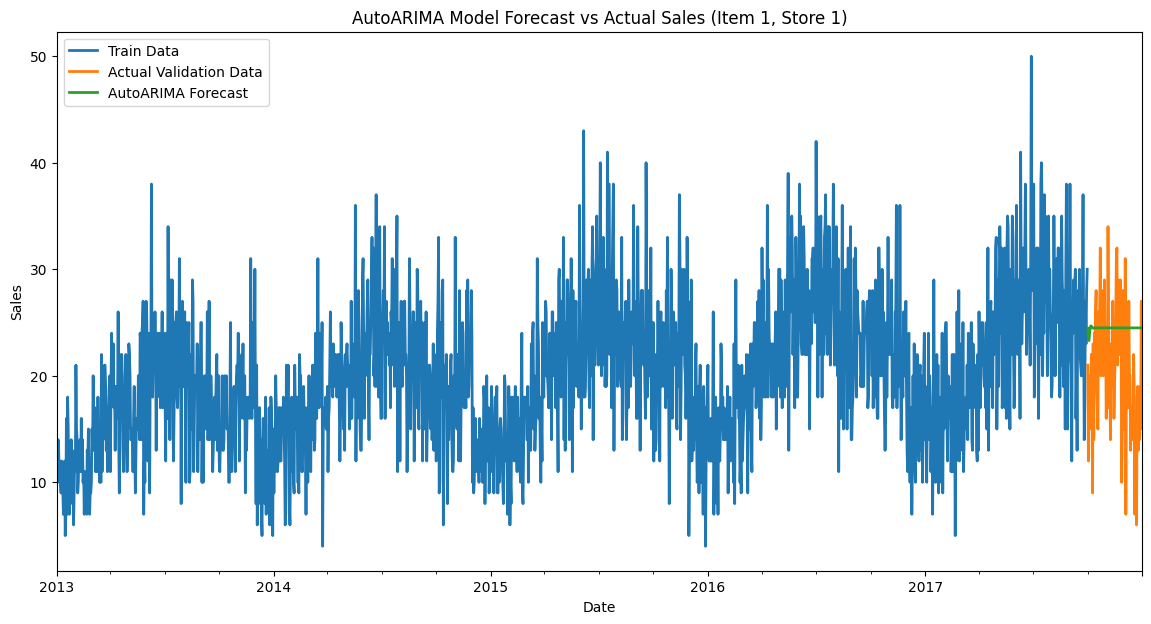

MAPE for AutoARIMA model: 40.63%


In [34]:
from darts.models import AutoARIMA
model_autoarima = AutoARIMA(
    start_p=0, d=None, max_p=3,
    start_q=0, max_q=3,
    start_P=0, D=None, max_P=2,
    start_Q=0, max_Q=2,
    max_d=2, max_D=1,
    seasonal=True,
    stepwise=True
)

model_autoarima.fit(train_series)
autoarima_forecast = model_autoarima.predict(len(val_series))

plt.figure(figsize=(14, 7))
train_series.plot(label='Train Data')
val_series.plot(label='Actual Validation Data')
autoarima_forecast.plot(label='AutoARIMA Forecast')
plt.title('AutoARIMA Model Forecast vs Actual Sales (Item 1, Store 1)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# MAPE
mape_autoarima = mape(val_series, autoarima_forecast)
print(f"MAPE for AutoARIMA model: {mape_autoarima:.2f}%")

Observation: MAPE = 40.63%. This indicates that, for this particular dataset, the automatic selection of AutoARIMA parameters did not yield a model with better results

14. Натренуйте модель Prophet та зробіть висновок про її якість.

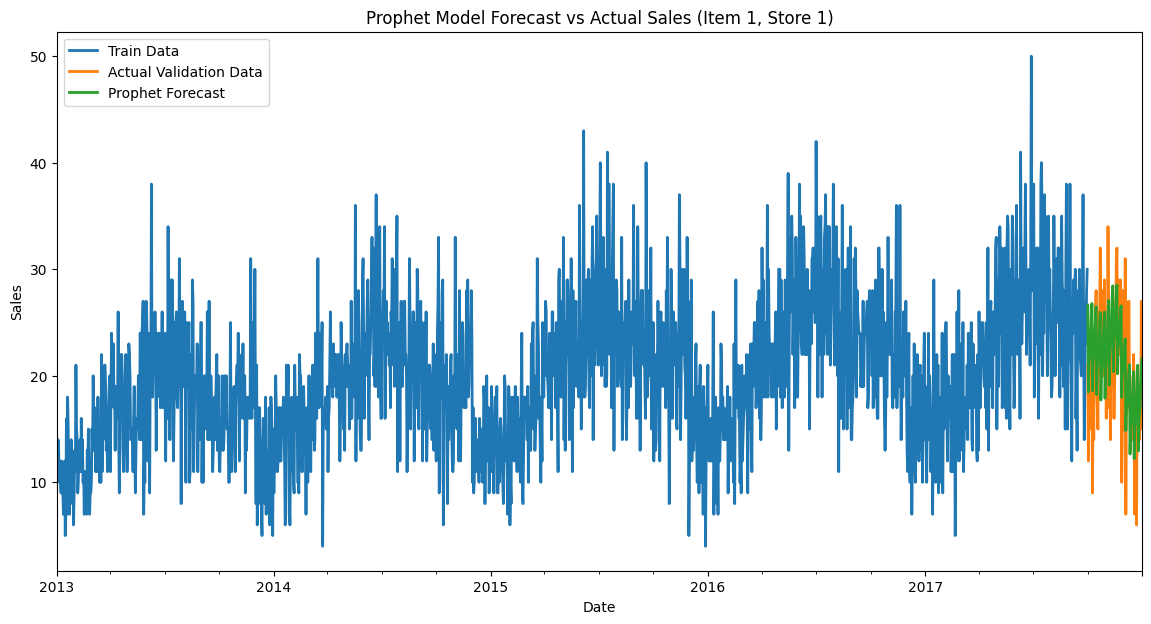

MAPE for Prophet model: 23.80%


In [37]:
prophet_train_df = pd.DataFrame({
    'ds': train_series.time_index,
    'y': train_series.values().flatten()
})

prophet_val_df = pd.DataFrame({
    'ds': val_series.time_index,
    'y': val_series.values().flatten()
})

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model_prophet.fit(prophet_train_df)
future = model_prophet.make_future_dataframe(periods=len(val_series), freq='D')
forecast = model_prophet.predict(future)

prophet_forecast_df = forecast[['ds', 'yhat']][forecast['ds'].isin(prophet_val_df['ds'])]
prophet_forecast_df.rename(columns={'ds': 'date', 'yhat': 'sales'}, inplace=True)
prophet_forecast_df.set_index('date', inplace=True)

prophet_forecast = TimeSeries.from_dataframe(prophet_forecast_df, value_cols='sales')

plt.figure(figsize=(14, 7))
train_series.plot(label='Train Data')
val_series.plot(label='Actual Validation Data')
prophet_forecast.plot(label='Prophet Forecast')
plt.title('Prophet Model Forecast vs Actual Sales (Item 1, Store 1)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# MAPE
mape_prophet = mape(val_series, prophet_forecast)
print(f"MAPE for Prophet model: {mape_prophet:.2f}%")

Observations: Prophet model MAPE = 23.80%. This is a significant improvement compared to other models. Visually, Prophet effectively captures both the underlying trend and strong weekly and annual seasonal patterns in the sales

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.